# 🇮🇹 Italian Railway Network — Data Inspection, Cleaning & EDA

**Dataset:** [Rail Disruption Prediction — Nature Scientific Data](https://www.nature.com/articles/s41597-025-06385-8)  
**Operator:** Trenitalia / RFI (Rete Ferroviaria Italiana)

This dataset covers the Italian national rail network across four files:

| File | Rows | Description |
|------|------|-------------|
| `Train_operation_data.csv` | ~2.6 M | Stop-level daily operations with delays, weather & faults |
| `Adjacent_railway_stations_mileage_data.csv` | ~12 K | Route station order, coordinates, cumulative mileage |
| `Train_station_locations_data.csv` | 591 | Station master: coordinates, region, short codes |
| `Train_fault_information.csv` | 113 | Fault/disruption logs with line, cause & duration |

**Period of interest:** January 1, 2024 → June 30, 2024

---

## 1 · Setup and Imports

We import the full data-science stack. `warnings` suppresses noisy pandas FutureWarnings. Global `rcParams` ensure consistent figure aesthetics across all plots without repeating style calls.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Global visual style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":         130,
    "figure.figsize":     (13, 5),
    "axes.titlesize":     14,
    "axes.titleweight":   "bold",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
})

SEED = 42
print("✓  Libraries loaded")

✓  Libraries loaded


---
## 2 · Loading the Auxiliary (Small) Datasets

We load the three smaller reference files first. This gives us the station coordinates, route mileages, and fault logs we need before touching the 600 MB operational file.

### 2.1 · Adjacent Railway Stations Mileage

Each row represents a station within a specific train route, recording its order along that route and cumulative kilometre distance from the origin. The `lat`/`lon` columns here correspond to the route's track geometry rather than the station master coordinates.

In [2]:
mileage = pd.read_csv("Adjacent_railway_stations_mileage_data.csv")

print(f"Shape: {mileage.shape}")
mileage.info()
display(mileage.head(5))

Shape: (12173, 7)
<class 'pandas.DataFrame'>
RangeIndex: 12173 entries, 0 to 12172
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   train_id       12173 non-null  str    
 1   route_id       12173 non-null  int64  
 2   station_name   12173 non-null  str    
 3   station_order  12173 non-null  int64  
 4   lat            12173 non-null  float64
 5   lon            12173 non-null  float64
 6   distance       12173 non-null  str    
dtypes: float64(2), int64(2), str(3)
memory usage: 665.8 KB


,train_id,route_id,station_name,station_order,lat,lon,distance
0,IC_1539,73,SAVONA,1,44.306892,8.470259,0
1,IC_1539,73,GENOVA P.PRINCIPE,2,44.417784,8.920700,40.5
2,IC_1539,73,VOGHERA,3,44.997800,9.007942,64.82
3,IC_1539,73,PAVIA,4,45.188843,9.144674,23.8
4,IC_1539,73,MILANO CENTRALE,5,45.486347,9.204528,33.4


### 2.2 · Train Station Locations

The station master file contains 591 stations with their official GPS coordinates and administrative region IDs. `id_region` follows the Italian NUTS-2 regional coding scheme.

In [3]:
stations = pd.read_csv("Train_station_locations_data.csv", encoding="cp1252")

# Normalise station name to uppercase for consistent merging later
stations["name"] = stations["name"].str.strip().str.upper()

print(f"Shape: {stations.shape}")
print(f"Regions covered: {stations['id_region'].nunique()}")
stations.info()
display(stations.head(5))

Shape: (2976, 6)
Regions covered: 20
<class 'pandas.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        2976 non-null   str    
 1   station_id  2976 non-null   str    
 2   name_short  2975 non-null   str    
 3   lat         2976 non-null   float64
 4   lon         2976 non-null   float64
 5   id_region   2955 non-null   float64
dtypes: float64(3), str(3)
memory usage: 139.6 KB


,name,station_id,name_short,lat,lon,id_region
0,ABANO TERME,S05700,Abano Terme,45.355199,11.811533,5.0
1,ABBADIA LARIANA,S01416,Abbadia Lariana,45.895864,9.335175,3.0
2,ABBASANTA,S12873,Abbasanta,40.128801,8.817733,20.0
3,ABBIATEGRASSO,S01062,Abbiategrasso,45.400631,8.921305,3.0
4,ACATE,S12409,Acate,36.996592,14.425450,19.0


### 2.3 · Train Fault Information

The fault log contains 113 disruption events reported by Trenitalia / RFI. Three critical parsing steps:
1. **`encoding='latin1'`** — Italian text with accented characters (è, ò, à) and Windows-1252 punctuation would raise a `UnicodeDecodeError` with the default UTF-8 decoder.
2. **Date parsing** — the raw format is `YYYY/M/D` (e.g. `2024/9/20`), which pandas cannot auto-infer; we specify `format='%Y/%m/%d'`.
3. **Delay duration** — values like `"40 min"` and `"20min"` (inconsistent spacing) are parsed by stripping non-numeric characters.

In [4]:
faults = pd.read_csv(
    "Train_fault_information.csv",
    encoding="latin1",
)

# ── Parse date ────────────────────────────────────────────────────────────────
faults["date"] = pd.to_datetime(
    faults["date"], format="%Y/%m/%d", errors="coerce"
)

# ── Parse delay duration  ("40 min" / "20min" → numeric minutes) ──────────────
faults["delay_minutes"] = (
    faults["delay_duration"]
    .astype(str)
    .str.replace(r"[^0-9]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce")
)

# ── Normalise line name (strip whitespace) ────────────────────────────────────
faults["line"] = faults["line"].str.strip()

print(f"Shape: {faults.shape}")
print(f"Date range: {faults['date'].min().date()} → {faults['date'].max().date()}")
print(f"Unique lines affected: {faults['line'].nunique()}")
faults.info()
display(faults[["date", "line", "delay_duration", "delay_minutes"]].head(6))

Shape: (113, 5)
Date range: 2024-09-20 → 2024-09-30
Unique lines affected: 89
<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            113 non-null    datetime64[us]
 1   line            101 non-null    str           
 2   delay_reason    113 non-null    str           
 3   delay_duration  81 non-null     str           
 4   delay_minutes   81 non-null     float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 4.5 KB


,date,line,delay_duration,delay_minutes
0,2024-09-20,Milan - Genoa,40 min,40.0
1,2024-09-20,High Speed ??Rome - Naples,60 min,60.0
2,2024-09-20,Genoa - Ventimiglia,40 min,40.0
3,2024-09-20,Venice - Milan,30 min,30.0
4,2024-09-20,Salerno - Naples via Monte del Vesuvio,30 min,30.0
5,2024-09-20,High Speed ??Rome - Florence,50 min,50.0


---
## 3 · Optimised Loading & Cleaning of the Operational Data

At ~600 MB and 2.6 million rows, loading the operational file naïvely would consume several gigabytes of RAM once pandas builds its in-memory representation. We use two strategies:

1. **`chunksize`** — stream the file in batches of 250 000 rows; filter each batch to the target date window before keeping it. This means we never hold the full raw file in memory.
2. **`dtype` pre-declaration** — telling pandas the expected types for unambiguous columns avoids the expensive type-inference pass on every chunk.

### 3.1 · Chunked Load with Date Filtering

In [5]:
DATE_START = pd.Timestamp("2024-01-01")
DATE_END   = pd.Timestamp("2024-06-30")
CHUNK_SIZE = 250_000

# Declare dtypes for unambiguous columns upfront
# (delay columns left as str because they contain 'S' and 'N' sentinels)
DTYPE_MAP = {
    "train_number": "int32",
    "station_order": "int16",
    "scheduled_running_time": "int32",
    "scheduled_stop_time": "int16",
    "week": "int8",
    "wind_speed": "float32",
    "temperature_min": "float32",
    "temperature_max": "float32",
    "initial_delay": "string",
    "final_delay": "string",
}

kept_chunks = []
total_raw   = 0
total_kept  = 0

reader = pd.read_csv(
    "Train_operation_data.csv",
    chunksize=CHUNK_SIZE,
    dtype=DTYPE_MAP,
    low_memory=False,
    parse_dates=["date"],
)

for i, chunk in enumerate(reader):
    total_raw += len(chunk)

    # Strict date filter — keep Jan 1 to Jun 30, 2024
    mask = (chunk["date"] >= DATE_START) & (chunk["date"] <= DATE_END)
    chunk = chunk.loc[mask].copy()

    total_kept += len(chunk)
    if len(chunk) > 0:
        kept_chunks.append(chunk)

    print(f"  Chunk {i+1:>2}: {total_raw:>10,} rows read │ {total_kept:>10,} kept", end="\r")

ops = pd.concat(kept_chunks, ignore_index=True)

del kept_chunks

print(f"\n\nFinal shape after date filter : {ops.shape}")
print(f"Date range                    : {ops['date'].min().date()} → {ops['date'].max().date()}")

  Chunk 11:  2,678,291 rows read │  2,678,291 kept

Final shape after date filter : (2678291, 30)
Date range                    : 2024-01-01 → 2024-06-30


### 3.2 · Cleaning the Delay Columns

The three delay columns (`arrival_delay`, `departure_delay`, `final_delay`) contain two special sentinel strings:

| Sentinel | Meaning | Action |
|----------|---------|--------|
| `"N"` | *Nessun dato* — first stop of a service (no inbound arrival) | Convert to `NaN` |
| `"S"` | *Soppresso* — the stop/service was **cancelled** | Set `cancelled = True`, delay → `NaN` |

We extract cancellation before coercing so the information is not silently lost.

In [6]:
def clean_delay_column(series: pd.Series, name: str):
    """
    Parse an Italian rail delay column.

    Returns
    -------
    numeric_series : float32 — delay in minutes (NaN for N / S entries)
    cancelled_mask : bool    — True where sentinel was 'S' (Soppresso)
    """
    s = series.astype(str).str.strip()

    cancelled_mask = s == "S"
    n_cancelled    = cancelled_mask.sum()
    n_first_stop   = (s == "N").sum()

    # Replace sentinels with NaN so pd.to_numeric can coerce cleanly
    s = s.replace({"N": np.nan, "S": np.nan})
    numeric = pd.to_numeric(s, errors="coerce").astype("float32")

    print(
        f"  {name:20s}: "
        f"{n_cancelled:>7,} cancelled (S) │ "
        f"{n_first_stop:>8,} first-stop (N) │ "
        f"{numeric.notna().sum():>10,} numeric values retained"
    )
    return numeric, cancelled_mask


print("Delay column parsing summary:")
ops["arrival_delay"],   arr_cancelled = clean_delay_column(ops["arrival_delay"],   "arrival_delay")
ops["departure_delay"], dep_cancelled = clean_delay_column(ops["departure_delay"], "departure_delay")

# final_delay is already int16 from dtype map — but check for sentinels just in case
if ops["final_delay"].dtype == object:
    ops["final_delay"], _ = clean_delay_column(ops["final_delay"], "final_delay")

# A stop is cancelled if either arrival OR departure is marked 'S'
ops["cancelled"] = (arr_cancelled | dep_cancelled).astype(bool)

print(f"\n  ► Cancelled stops   : {ops['cancelled'].sum():>10,}  ({ops['cancelled'].mean()*100:.2f}% of all stops)")
print(f"  ► Non-cancelled     : {(~ops['cancelled']).sum():>10,}")

Delay column parsing summary:
  arrival_delay       :  17,279 cancelled (S) │  342,586 first-stop (N) │  2,318,426 numeric values retained
  departure_delay     :  17,279 cancelled (S) │  342,503 first-stop (N) │  2,318,509 numeric values retained

  ► Cancelled stops   :     17,279  (0.65% of all stops)
  ► Non-cancelled     :  2,661,012


### 3.3 · Weather Severity Mapping

The `weather` column contains seven categorical conditions recorded at the station at the time of the service. We create a companion `weather_severity` column (0–4 ordinal scale) to enable quantitative weather–delay correlation analysis. The scale roughly follows precipitation intensity and expected impact on rail operations.

In [7]:
WEATHER_SEVERITY = {
    "cloudy":        0,
    "light rain":    1,
    "moderate rain": 2,
    "heavy rain":    3,
    "light snow":    2,   # snow has higher impact per mm than rain
    "moderate snow": 3,
    "heavy snow":    4,
}

# Ordered list for consistent plot ordering
WEATHER_ORDER = [
    "cloudy", "light rain", "moderate rain", "heavy rain",
    "light snow", "moderate snow", "heavy snow",
]

ops["weather"] = ops["weather"].str.strip().str.lower()
ops["weather_severity"] = ops["weather"].map(WEATHER_SEVERITY).astype("Int8")

print("Weather value counts:")
weather_vc = ops["weather"].value_counts()
display(
    weather_vc.rename("stops")
    .to_frame()
    .assign(pct=lambda d: (d["stops"] / len(ops) * 100).round(2))
)

Weather value counts:


,stops,pct
weather,,
cloudy,1016993,37.97
light rain,1011540,37.77
moderate rain,351180,13.11
sunny,116659,4.36
partially cloudy,64817,2.42
heavy rain,56102,2.09
moderate snow,26583,0.99
heavy snow,17972,0.67
light snow,16445,0.61


### 3.4 · Additional Type Optimisation

Converting high-cardinality string columns to `category` dtype reduces memory usage significantly — a `category` column stores each unique string once and uses an integer index internally.

In [8]:
CAT_COLS = [
    "train_class", "weather", "station_name",
    "first_station_name", "final_station_name", "train_id",
]
for col in CAT_COLS:
    if col in ops.columns:
        ops[col] = ops[col].astype("category")

ops["holiday"] = ops["holiday"].astype(bool)

print(f"Memory usage after optimisation: {ops.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Shape: {ops.shape}")
print(f"\nTrain classes present: {ops['train_class'].cat.categories.tolist()}")
ops.head(3)

Memory usage after optimisation: 1423.8 MB
Shape: (2678291, 32)

Train classes present: ['EC', 'FA', 'FB', 'FR', 'IC', 'ICN', 'REG']


,train_class,train_number,first_station_name,final_station_name,scheduled_departure_station,scheduled_arrival_station,fault_describe,initial_delay,final_delay,date,...,actual_running_time,actual_stop_time,week,holiday,temperature_min,temperature_max,weather,wind_speed,cancelled,weather_severity
0,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1,-1,2024-01-01,...,0.0,0.0,1,True,0.7,8.7,cloudy,12.0,False,0
1,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1,-1,2024-01-01,...,39.0,4.0,1,True,2.8,11.3,cloudy,13.3,False,0
2,EC,150,MILANO CENTRALE,CHIASSO,NaN,NaN,NaN,1,-1,2024-01-01,...,3.0,0.0,1,True,2.8,11.3,cloudy,13.3,False,0


---
## 4 · Missing Values & Data Quality Check

A structured missing-value audit before any analysis. We separate the results into **operational columns** and **weather columns** because their missingness has different structural causes:

- `arrival_delay` is structurally `NaN` for the **first stop** of every service (no inbound leg exists)
- `departure_delay` is structurally `NaN` for the **last stop** (no outbound leg)
- Weather columns can be missing when the matched meteorological station had no reading for that hour

In [9]:
def missing_summary(frame: pd.DataFrame, label: str = "") -> pd.DataFrame:
    n = len(frame)
    summary = (
        frame.isnull()
             .sum()
             .rename("missing_count")
             .to_frame()
             .assign(
                 missing_pct = lambda d: (d["missing_count"] / n * 100).round(2),
                 dtype       = frame.dtypes.astype(str),
             )
             .sort_values("missing_pct", ascending=False)
    )
    summary.index.name = "column"
    if label:
        print(f"\n{'─'*55}  {label}  (n={n:,})  {'─'*5}")
    return summary


miss = missing_summary(ops, "Train_operation_data (cleaned)")
display(miss)


───────────────────────────────────────────────────────  Train_operation_data (cleaned)  (n=2,678,291)  ─────


,missing_count,missing_pct,dtype
column,,,
fault_describe,2670220,99.70,str
scheduled_departure_station,2670008,99.69,str
scheduled_arrival_station,2670008,99.69,str
arrival_delay,359865,13.44,float32
departure_delay,359782,13.43,float32
weather_severity,181476,6.78,Int8
actual_stop_time,17279,0.65,float64
actual_departure_time,17278,0.65,str
actual_running_time,17279,0.65,float64


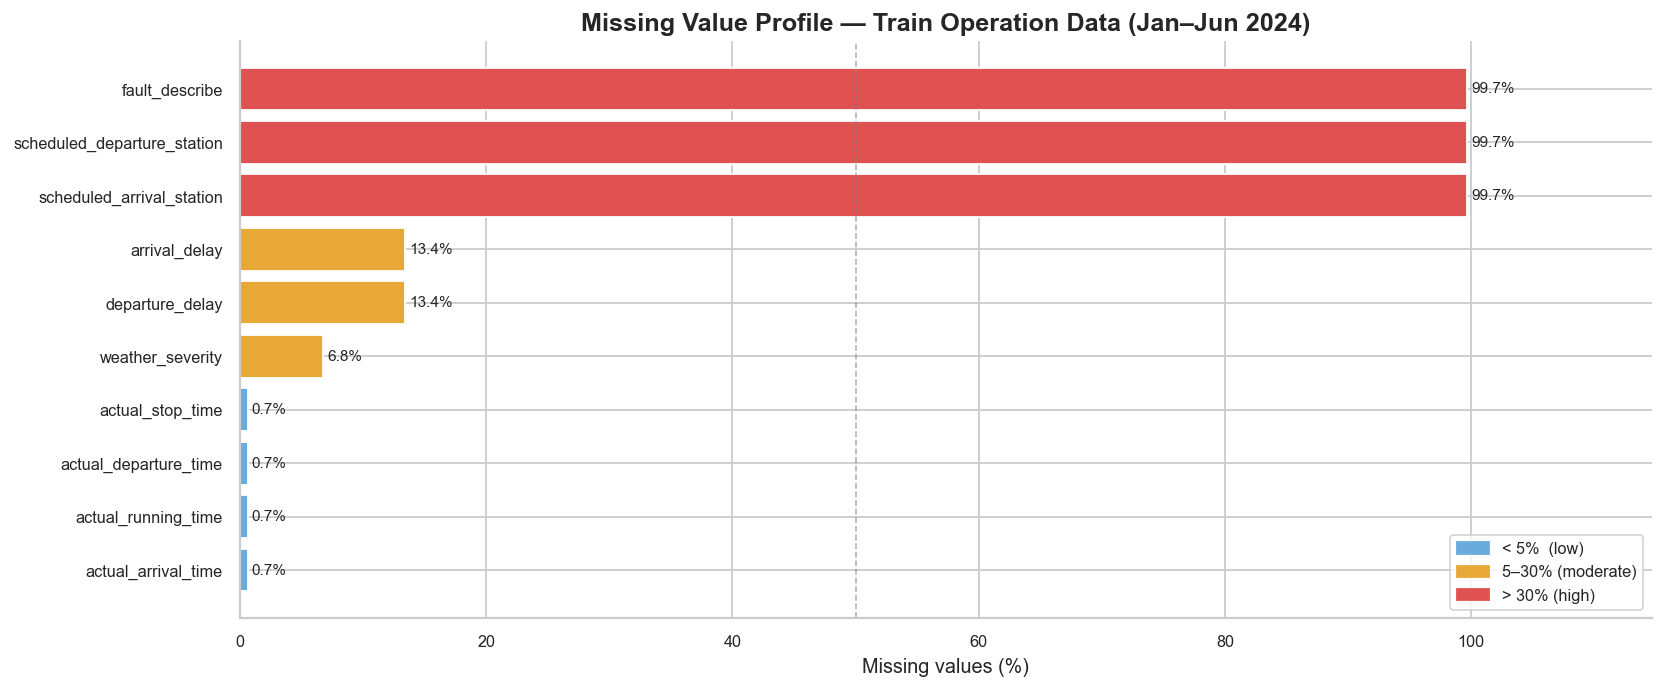

In [10]:
# ── Visual missing-value bar chart ────────────────────────────────────────────
cols_with_miss = miss[miss["missing_pct"] > 0]

if cols_with_miss.empty:
    print("No missing values — dataset is complete.")
else:
    fig, ax = plt.subplots(figsize=(13, max(4, len(cols_with_miss) * 0.55)))

    bar_colors = [
        "#e05252" if p > 30 else "#e8a838" if p > 5 else "#6aabde"
        for p in cols_with_miss["missing_pct"]
    ]
    ax.barh(
        cols_with_miss.index[::-1],
        cols_with_miss["missing_pct"][::-1],
        color=bar_colors[::-1],
        edgecolor="white",
    )
    for i, (col, row) in enumerate(cols_with_miss[::-1].iterrows()):
        ax.text(
            row["missing_pct"] + 0.3, i,
            f"{row['missing_pct']:.1f}%",
            va="center", fontsize=8.5,
        )

    ax.axvline(50, color="grey", ls="--", lw=0.9, alpha=0.6, label="50% threshold")
    ax.set_xlabel("Missing values (%)")
    ax.set_title("Missing Value Profile — Train Operation Data (Jan–Jun 2024)")
    ax.set_xlim(0, max(cols_with_miss["missing_pct"]) * 1.15)

    # Legend for colour bands
    patches = [
        mpatches.Patch(color="#6aabde", label="< 5%  (low)"),
        mpatches.Patch(color="#e8a838", label="5–30% (moderate)"),
        mpatches.Patch(color="#e05252", label="> 30% (high)"),
    ]
    ax.legend(handles=patches, fontsize=9, loc="lower right")
    plt.tight_layout()
    plt.show()

---
## 5 · Exploratory Data Analysis (EDA)

All five visualisations are designed around the **disruption prediction** use-case of the paper: understanding which trains, stations, and conditions drive delays.

---

### 5.1 · The Italian Railway Map

We visualise the spatial footprint of the station network using the official GPS coordinates from `Train_station_locations_data.csv`. Stations are coloured by administrative region (`id_region`) to highlight the North–South geographic structure of the Italian network. The characteristic "boot" shape of the peninsula should be clearly visible.

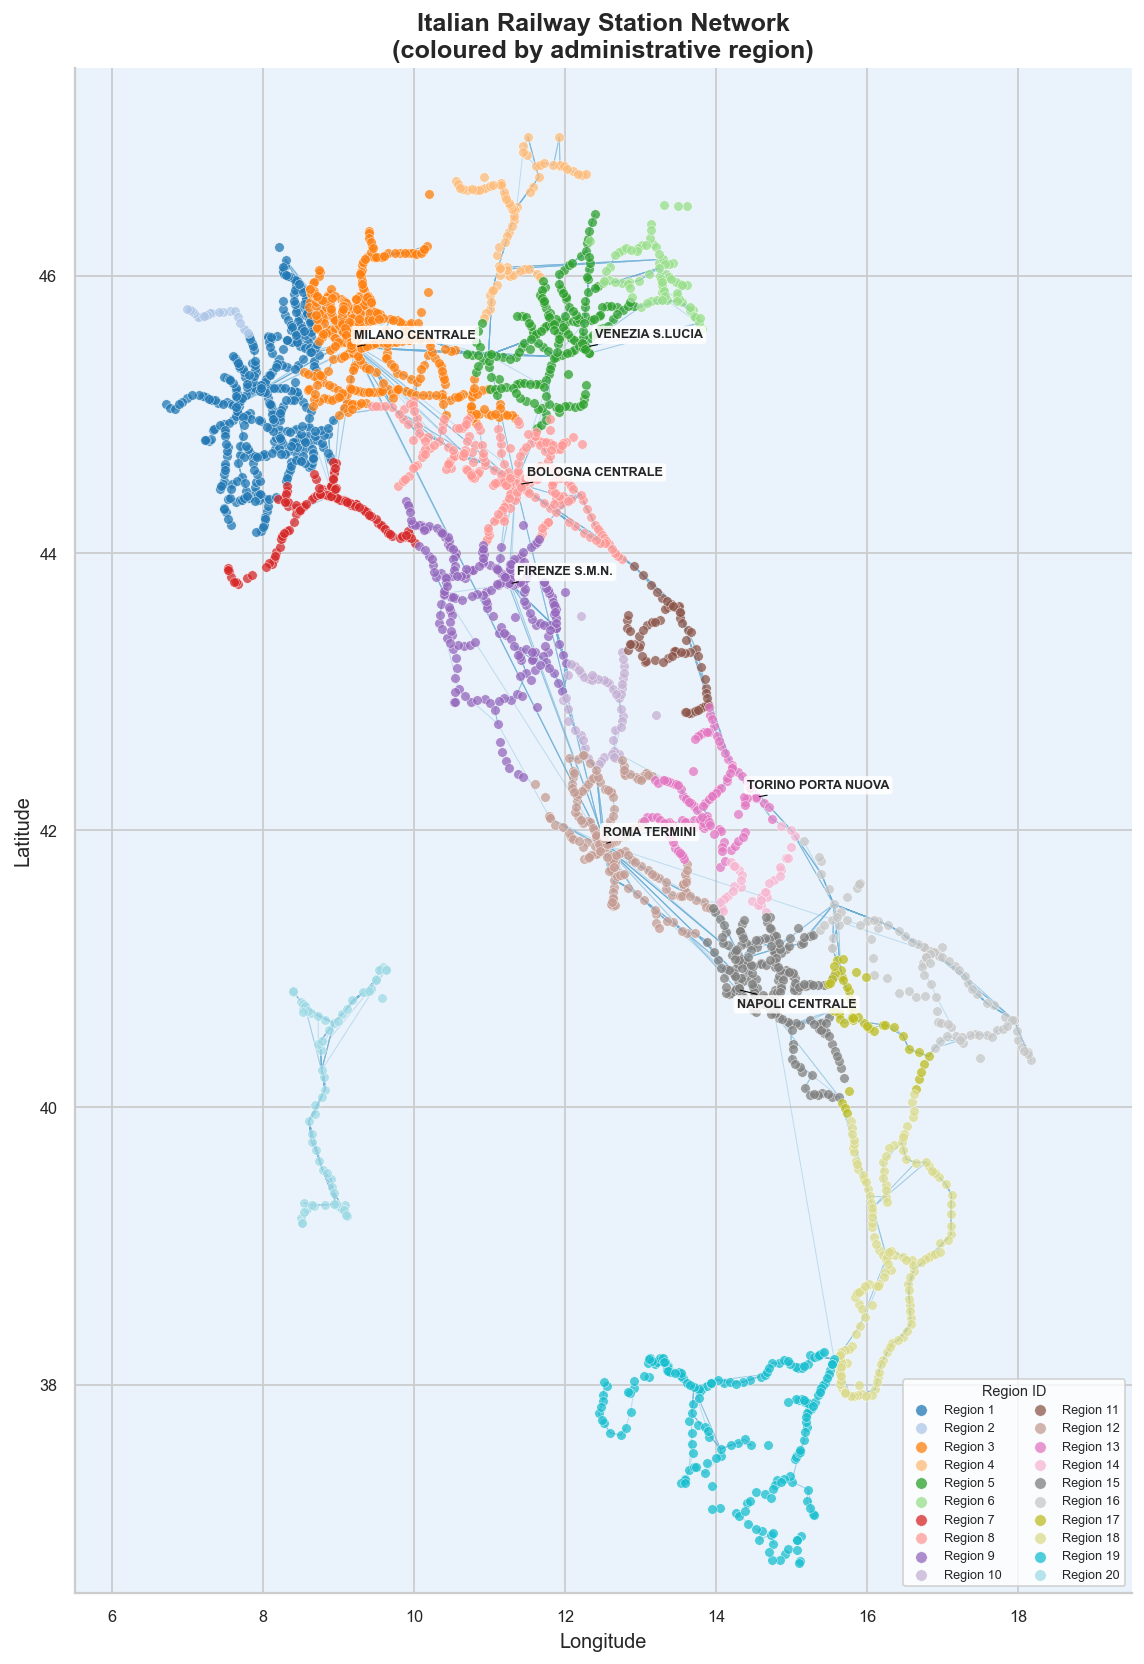

Stations plotted: 2976  |  Routes drawn: 1287


In [11]:
fig, ax = plt.subplots(figsize=(9, 13))

# Colour-code by region
regions = stations["id_region"].dropna().unique()
palette = sns.color_palette("tab20", n_colors=len(regions))
color_map = dict(zip(sorted(regions), palette))

for region, grp in stations.groupby("id_region"):
    ax.scatter(
        grp["lon"], grp["lat"],
        s=28,
        color=color_map.get(region, "grey"),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.3,
        label=f"Region {int(region)}",
        zorder=3,
    )

# Also draw mileage route lines (one per unique route_id) for network topology
route_palette = sns.color_palette("Blues", n_colors=3)
for _, route_df in mileage.groupby("route_id"):
    route_sorted = route_df.sort_values("station_order")
    ax.plot(
        route_sorted["lon"], route_sorted["lat"],
        color=route_palette[1], lw=0.55, alpha=0.35, zorder=1,
    )

# Annotate a handful of major hubs
MAJOR_STATIONS = {
    "ROMA TERMINI":       (0, 5),
    "MILANO CENTRALE":    (0, 5),
    "NAPOLI CENTRALE":    (0, -10),
    "TORINO PORTA NUOVA": (-5, 5),
    "VENEZIA S.LUCIA":    (5, 5),
    "BOLOGNA CENTRALE":   (5, 5),
    "FIRENZE S.M.N.":     (5, 5),
}

for name, (dx, dy) in MAJOR_STATIONS.items():
    row = stations[stations["name"] == name]
    if row.empty:
        # Try partial match
        row = stations[stations["name"].str.contains(name.split()[0], na=False)].head(1)
    if not row.empty:
        ax.annotate(
            name,
            xy=(row["lon"].values[0], row["lat"].values[0]),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, fontweight="bold",
            arrowprops=dict(arrowstyle="-", lw=0.6, color="black"),
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85, lw=0),
        )

ax.set_title("Italian Railway Station Network\n(coloured by administrative region)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(5.5, 19.5)
ax.set_ylim(36.5, 47.5)
ax.legend(
    loc="lower right", fontsize=7, ncol=2,
    title="Region ID", title_fontsize=8,
    markerscale=1.2,
)
ax.set_facecolor("#eaf3fb")
plt.tight_layout()
plt.show()

print(f"Stations plotted: {len(stations)}  |  Routes drawn: {mileage['route_id'].nunique()}")

### 5.2 · Delay Distribution by Train Class

Italy's Trenitalia operates multiple service tiers:

| Code | Service | Characteristics |
|------|---------|------------------|
| `FR` | Frecciarossa (high-speed) | 300 km/h, dedicated HS infrastructure |
| `FA` | Frecciargento | Tilting train, mixed HS/conventional |
| `FB` | Frecciabianca | Conventional routes, HS speed |
| `EC` | EuroCity | International cross-border |
| `IC` | InterCity | Domestic long-distance |
| `ICN` | InterCity Notte | Overnight sleeper |

We show both **mean delay** (sensitivity to outliers) and the **distribution shape** via boxplot to reveal whether high-mean classes suffer from chronic small delays or from occasional large disruptions.

,train_class,mean_delay,median_delay,std_delay,n_stops,pct_late
0,FR,5.82,3.0,12.970000,47897,46.009998
1,FA,7.12,4.0,14.910000,3269,51.060001
2,FB,4.14,2.0,9.200000,1958,43.259998
3,EC,8.10,4.0,15.360000,12723,53.680000
4,IC,7.11,3.0,16.969999,13414,45.680000
5,ICN,5.67,1.0,20.580000,3205,38.599998


/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_50941/3304816810.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


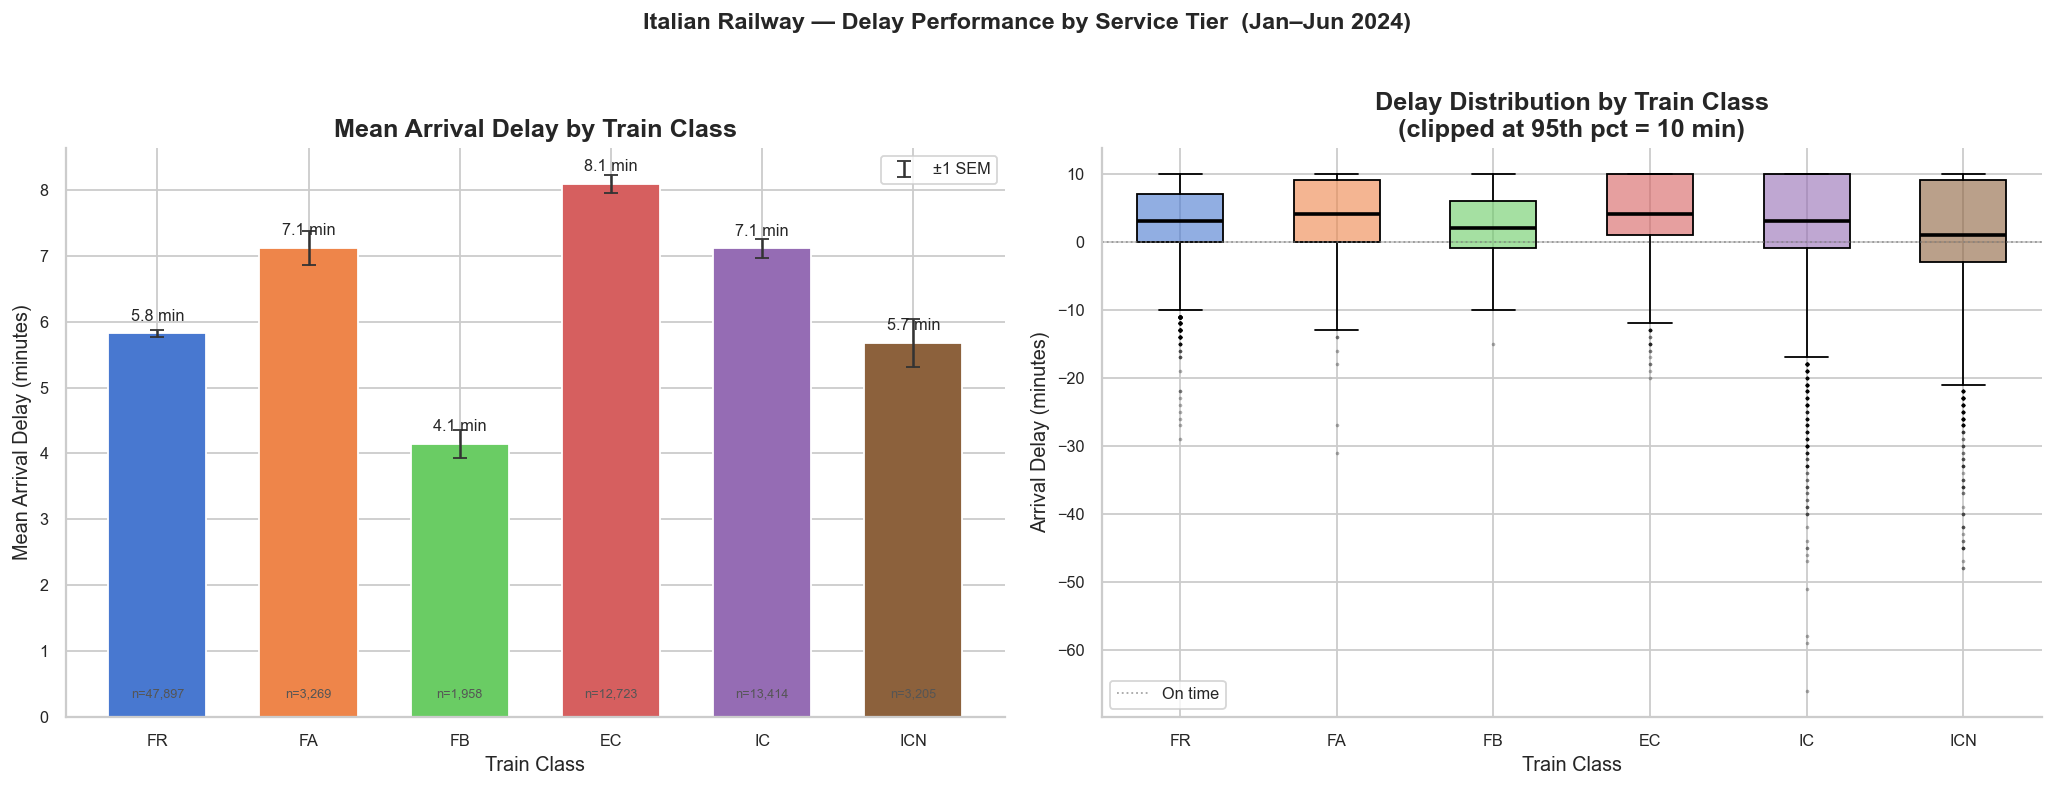

In [12]:
# Work only on non-cancelled stops with a valid arrival delay
ops_nc = ops[~ops["cancelled"] & ops["arrival_delay"].notna()].copy()

# ── Per-class summary statistics ──────────────────────────────────────────────
CLASS_ORDER = ["FR", "FA", "FB", "EC", "IC", "ICN"]
# Only keep classes that actually appear in the data
present_classes = [c for c in CLASS_ORDER if c in ops_nc["train_class"].cat.categories]

class_stats = (
    ops_nc
    .groupby("train_class", observed=True)["arrival_delay"]
    .agg(
        mean_delay   = "mean",
        median_delay = "median",
        std_delay    = "std",
        n_stops      = "count",
        pct_late     = lambda x: (x > 3).mean() * 100,
    )
    .reindex(present_classes)
    .reset_index()
)
display(class_stats.round(2))

# ── Figure: bar (mean delay) + boxplot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette("muted", n_colors=len(present_classes))

# -- Left: mean delay bar chart ------------------------------------------------
ax = axes[0]
bars = ax.bar(
    class_stats["train_class"], class_stats["mean_delay"],
    color=palette, edgecolor="white", width=0.65,
)
ax.errorbar(
    class_stats["train_class"], class_stats["mean_delay"],
    yerr=class_stats["std_delay"] / np.sqrt(class_stats["n_stops"]),
    fmt="none", color="#333", capsize=4, lw=1.4, label="±1 SEM",
)
for bar, row in zip(bars, class_stats.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{row.mean_delay:.1f} min",
        ha="center", va="bottom", fontsize=9,
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2, 0.25,
        f"n={row.n_stops:,}",
        ha="center", va="bottom", fontsize=7, color="#555",
    )
ax.set_title("Mean Arrival Delay by Train Class")
ax.set_xlabel("Train Class")
ax.set_ylabel("Mean Arrival Delay (minutes)")
ax.legend(fontsize=9)

# -- Right: boxplot (clipped to 95th pct for readability) ----------------------
ax2 = axes[1]
p95 = ops_nc["arrival_delay"].quantile(0.95)
plot_data = [
    ops_nc.loc[ops_nc["train_class"] == cls, "arrival_delay"].clip(upper=p95).dropna().values
    for cls in present_classes
]
bp = ax2.boxplot(
    plot_data,
    labels=present_classes,
    patch_artist=True,
    medianprops=dict(color="black", lw=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    widths=0.55,
)
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor((*color[:3], 0.6))   # add alpha

ax2.axhline(0, color="grey", ls=":", lw=1, alpha=0.7, label="On time")
ax2.set_title(f"Delay Distribution by Train Class\n(clipped at 95th pct = {p95:.0f} min)")
ax2.set_xlabel("Train Class")
ax2.set_ylabel("Arrival Delay (minutes)")
ax2.legend(fontsize=9)

plt.suptitle("Italian Railway — Delay Performance by Service Tier  (Jan–Jun 2024)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.3 · Weather Impact on Arrival Delays

Each stop record contains the weather condition at the matched meteorological station. We compare **mean arrival delay** across weather categories and overlay the **95% confidence interval** (via SEM). We also show cancellation rates per weather type to distinguish whether bad weather causes delays or full service suspensions.

> **Interpretation note:** The dataset merges station-level weather with stop-level operations — the weather condition reflects the atmospheric state at the *station*, not necessarily over the full route of the train.

,weather,mean_delay,sem_delay,cancellation_rate,n_stops
0,cloudy,2.491,0.006,0.668,879359
1,light rain,2.539,0.006,0.724,875203
2,moderate rain,2.856,0.011,0.356,307804
3,heavy rain,3.332,0.035,0.410,48900
4,light snow,2.623,0.048,0.572,14354
5,moderate snow,2.481,0.036,0.681,23094
6,heavy snow,2.863,0.060,0.579,15579


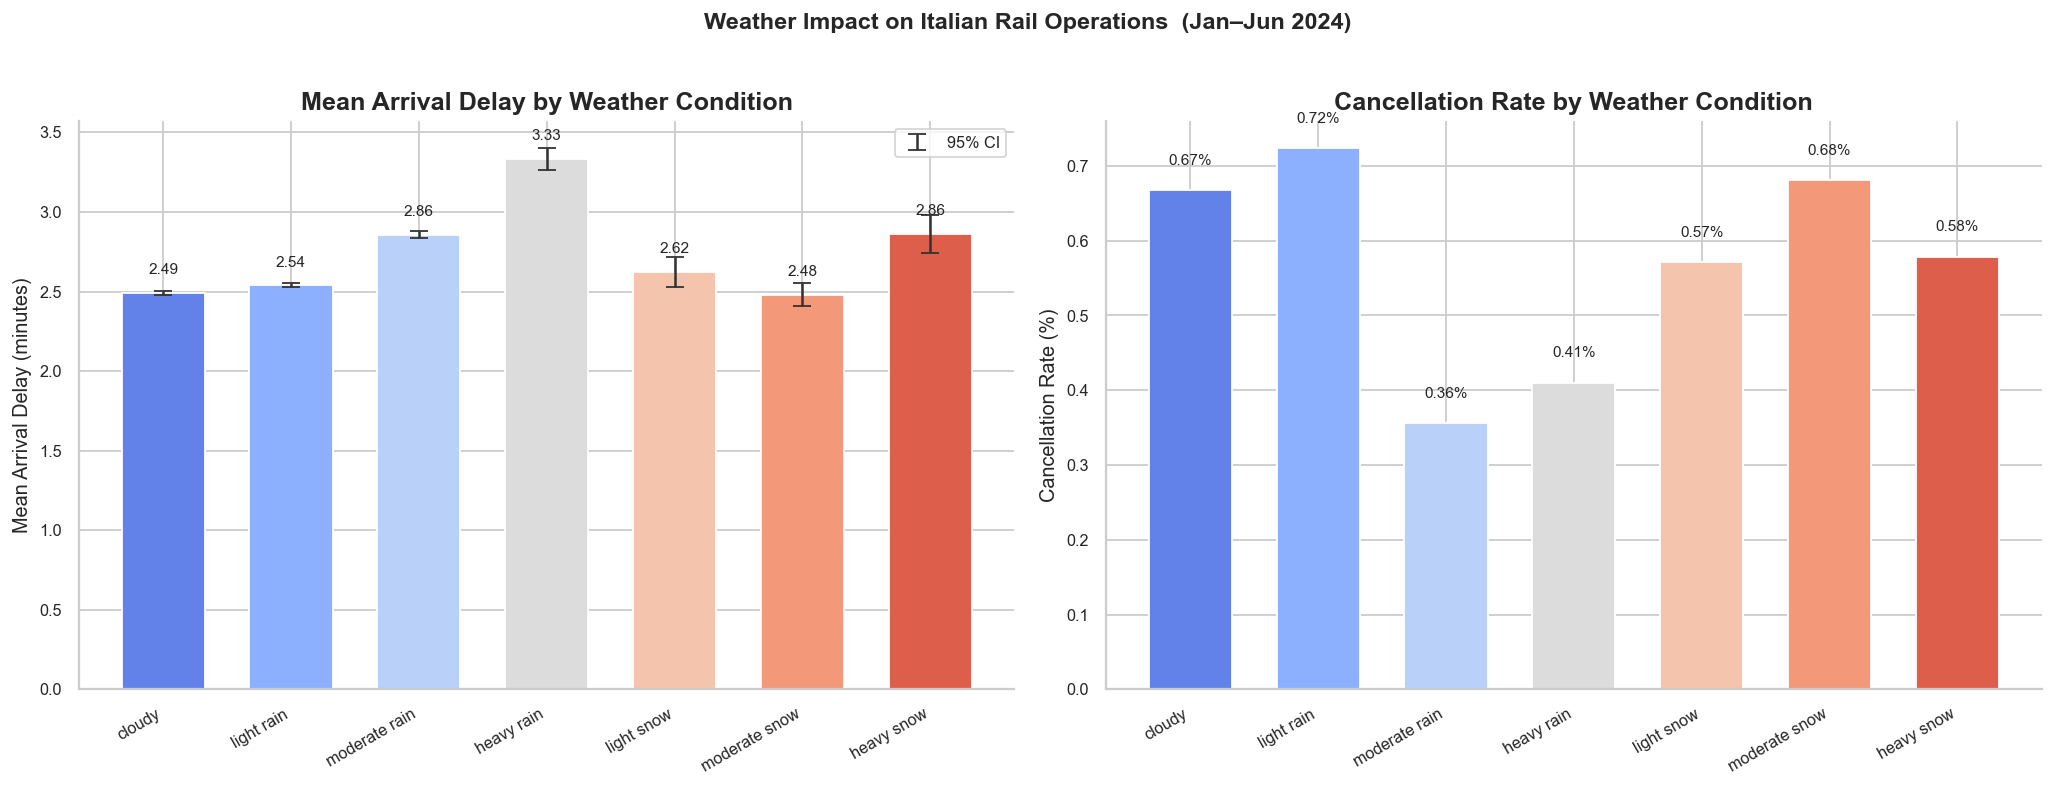

In [13]:
# Available weather categories in this 6-month window
available_weather = [w for w in WEATHER_ORDER if w in ops["weather"].cat.categories]

weather_stats = (
    ops
    .dropna(subset=["weather"])
    .groupby("weather", observed=True)
    .agg(
        mean_delay        = ("arrival_delay", lambda x: x[~ops.loc[x.index, "cancelled"]].mean()),
        sem_delay         = ("arrival_delay", lambda x: x[~ops.loc[x.index, "cancelled"]].sem()),
        cancellation_rate = ("cancelled",     "mean"),
        n_stops           = ("arrival_delay", "count"),
    )
    .reindex(available_weather)
    .reset_index()
)
weather_stats["cancellation_rate"] *= 100
display(weather_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_w = sns.color_palette("coolwarm", n_colors=len(available_weather))

# ── Left: mean delay with CI ─────────────────────────────────────────────────
ax = axes[0]
x = range(len(weather_stats))
bars = ax.bar(
    x, weather_stats["mean_delay"],
    color=colors_w, edgecolor="white", width=0.65,
)
ax.errorbar(
    x, weather_stats["mean_delay"],
    yerr=1.96 * weather_stats["sem_delay"],
    fmt="none", color="#333", capsize=5, lw=1.4, label="95% CI",
)
for bar, val in zip(bars, weather_stats["mean_delay"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=8.5,
    )
ax.set_xticks(x)
ax.set_xticklabels(
    weather_stats["weather"],
    rotation=30, ha="right",
)
ax.set_title("Mean Arrival Delay by Weather Condition")
ax.set_ylabel("Mean Arrival Delay (minutes)")
ax.legend(fontsize=9)

# ── Right: cancellation rate ─────────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(
    x, weather_stats["cancellation_rate"],
    color=colors_w, edgecolor="white", width=0.65,
)
for bar, val in zip(bars2, weather_stats["cancellation_rate"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.2f}%",
        ha="center", va="bottom", fontsize=8.5,
    )
ax2.set_xticks(x)
ax2.set_xticklabels(
    weather_stats["weather"],
    rotation=30, ha="right",
)
ax2.set_title("Cancellation Rate by Weather Condition")
ax2.set_ylabel("Cancellation Rate (%)")

plt.suptitle("Weather Impact on Italian Rail Operations  (Jan–Jun 2024)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.4 · Fault Frequency Time-Series

The `Train_fault_information.csv` logs 113 disruption events reported across the network. We plot:
1. **Daily fault count** (raw bar chart) to show the temporal pattern of disruptions
2. **7-day rolling mean** to smooth short-term noise and reveal medium-term trends
3. **Accumulated downtime per day** (right axis) to weight fault frequency by severity

> **Note:** The fault log covers a wider date range than the operations file. We show the full extent of the fault data to give complete context.

\subsubsection{Temporal Discrepancy in Disruption Logs}
During the exploratory data analysis, a critical temporal misalignment was identified between the primary operational data and the fault logs. While the \texttt{Train\_operation\_data.csv} covers a six-month continuous period from January to June 2024, the \texttt{Train\_fault\_information.csv} dataset acts merely as a localized sample, containing 113 recorded events exclusively occurring between September 20 and September 30, 2024. 

As a direct architectural consequence, these explicit textual fault logs cannot be used to label the target variable (\texttt{is\_disrupted}) for the main predictive model via join operations. Instead, the ground-truth disruption labels for the Italian network during the training phase (Jan-Jun) must be inferred purely from operational metrics (i.e., extreme delays and explicit 'S' cancellation sentinels), reserving the fault logs for isolated Explainable AI (XAI) demonstrations within the Knowledge Graph.

Fault log date range: 2024-09-20 → 2024-09-30
Total fault events  : 113
Days with ≥1 fault  : 10


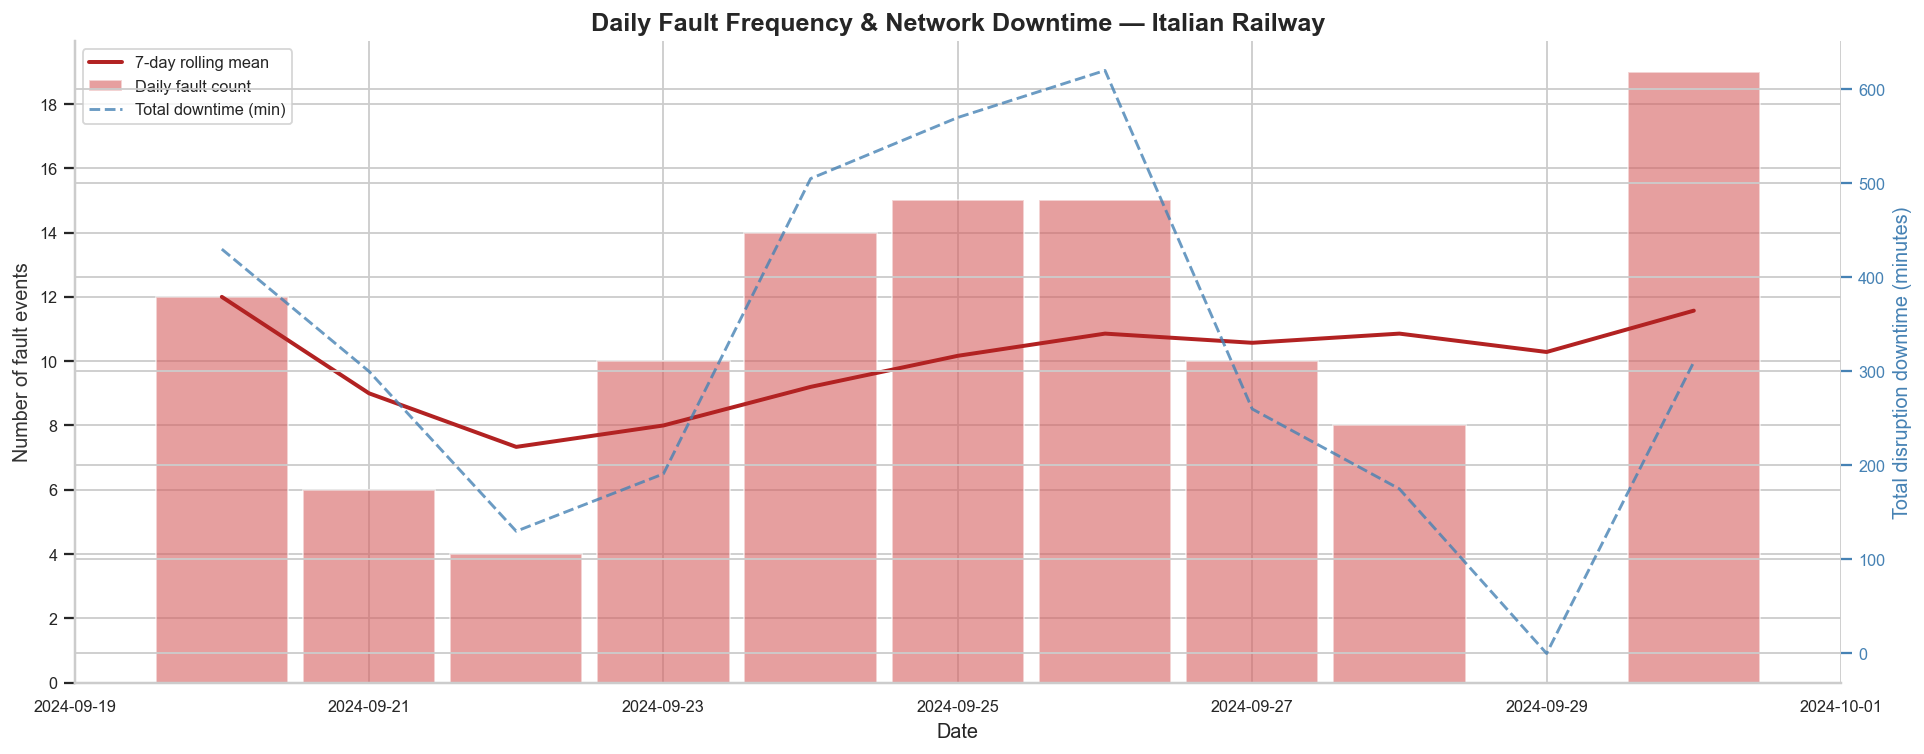

In [14]:
# ── Build daily fault counts ──────────────────────────────────────────────────
fault_daily = (
    faults
    .dropna(subset=["date"])
    .groupby("date")
    .agg(
        fault_count    = ("date",          "count"),
        total_downtime = ("delay_minutes", "sum"),
        lines_affected = ("line",          "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

# Fill any missing dates with zero (no fault recorded = no disruption)
date_idx = pd.date_range(
    start=fault_daily["date"].min(),
    end=fault_daily["date"].max(),
    freq="D",
)
fault_daily = (
    fault_daily.set_index("date")
               .reindex(date_idx, fill_value=0)
               .rename_axis("date")
               .reset_index()
)
fault_daily["rolling_7d"] = fault_daily["fault_count"].rolling(7, min_periods=1).mean()

print(f"Fault log date range: {fault_daily['date'].min().date()} → {fault_daily['date'].max().date()}")
print(f"Total fault events  : {faults['date'].notna().sum()}")
print(f"Days with ≥1 fault  : {(fault_daily['fault_count'] > 0).sum()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.bar(
    fault_daily["date"], fault_daily["fault_count"],
    color=sns.color_palette("muted")[3], alpha=0.6,
    label="Daily fault count", width=0.9,
)
ax1.plot(
    fault_daily["date"], fault_daily["rolling_7d"],
    color="firebrick", lw=2.2, label="7-day rolling mean",
)
ax1.set_ylabel("Number of fault events", color="#333")
ax1.set_xlabel("Date")
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right axis: cumulative downtime
ax2 = ax1.twinx()
ax2.plot(
    fault_daily["date"], fault_daily["total_downtime"],
    color="steelblue", lw=1.6, ls="--", alpha=0.8,
    label="Total downtime (min)",
)
ax2.set_ylabel("Total disruption downtime (minutes)", color="steelblue")
ax2.tick_params(axis="y", colors="steelblue")

# Shade the Jan–Jun 2024 window of interest
ax1.set_xlim(pd.Timestamp("2024-09-19"), pd.Timestamp("2024-10-01"))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Daily Fault Frequency & Network Downtime — Italian Railway",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

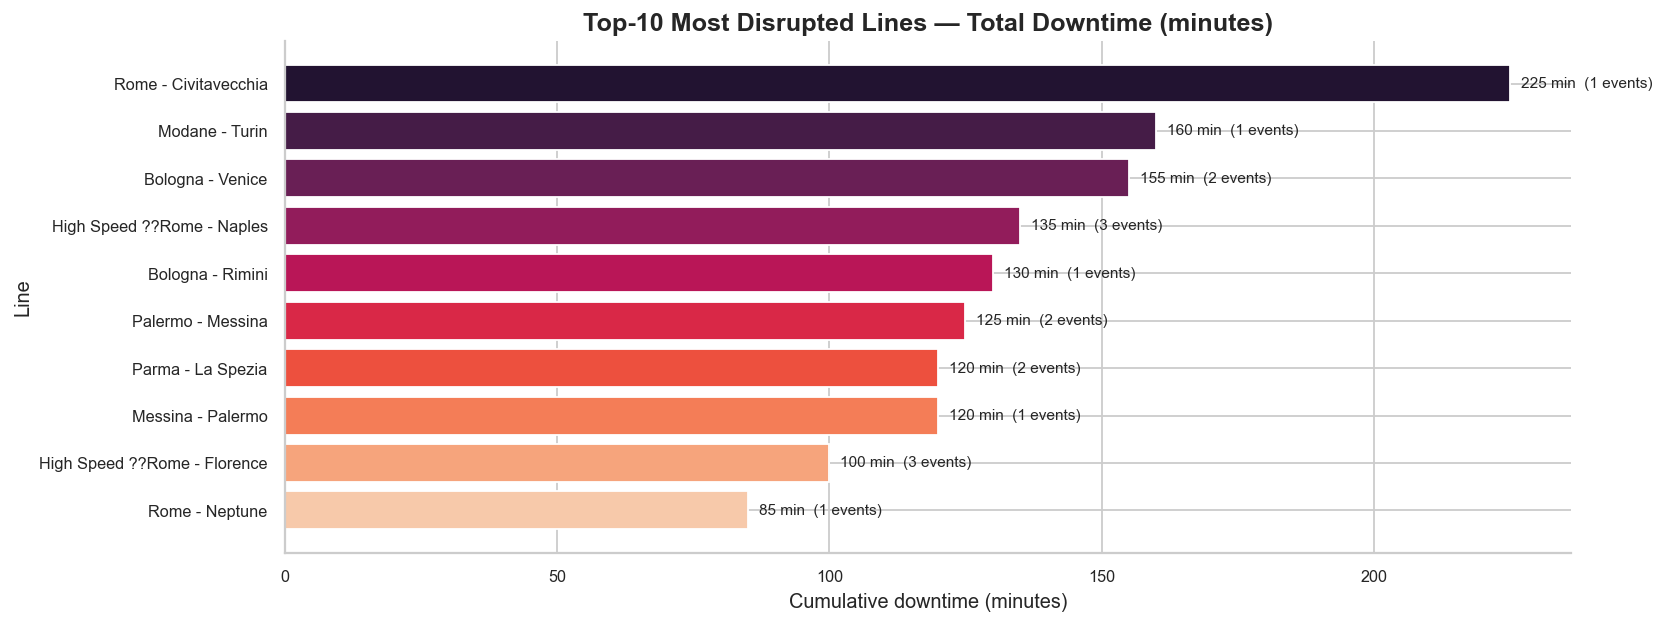

In [18]:
# ── Top-10 most affected lines ─────────────────────────────────────────────────
top_lines = (
    faults
    .groupby("line")
    .agg(
        events         = ("date",          "count"),
        total_downtime = ("delay_minutes", "sum"),
    )
    .sort_values("total_downtime", ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
palette_l = sns.color_palette("rocket", n_colors=len(top_lines))
ax.barh(
    top_lines["line"][::-1],
    top_lines["total_downtime"][::-1],
    color=palette_l[::-1], edgecolor="white",
)
for i, (_, row) in enumerate(top_lines[::-1].iterrows()):
    ax.text(
        row["total_downtime"] + 2, i,
        f"{row['total_downtime']:,.0f} min  ({row['events']} events)",
        va="center", fontsize=8.5,
    )
ax.set_title("Top-10 Most Disrupted Lines — Total Downtime (minutes)")
ax.set_xlabel("Cumulative downtime (minutes)")
ax.set_ylabel("Line")
plt.tight_layout()
plt.show()

### 5.5 · Top-10 Most Delayed Stations

We aggregate by `station_name` across the non-cancelled stops and compute:
- **Mean arrival delay** (primary ranking criterion)
- **Proportion of stops that arrive late (> 3 minutes)**
- **Cancellation rate**

Only stations with at least **200 stop observations** are included to prevent small-sample noise from pushing rarely-served sidings to the top.

We then join with `Train_station_locations_data.csv` to add geographic context and map the worst stations.

,station_name,mean_delay,pct_late,cancellation_rate,n_stops
0,VAIRANO,16.77,72.199997,1.63,241
1,CASERTA,11.07,48.610001,1.69,960
2,CASSINO,9.76,36.810001,2.70,494
3,POGGIO FIDONI,9.54,99.160004,0.00,478
4,LABRO MOGGIO,9.45,99.570000,0.21,468
5,MOSCIANO S. ANGELO,9.30,99.750000,0.00,405
6,CAPO D`ORLANDO-NASO,9.15,43.570000,0.94,1159
7,ARQUATA SCRIVIA,8.68,57.450001,2.49,216
8,ACCIANO,8.58,100.000000,0.00,401
9,ROMAGNANO V.,8.51,75.339996,0.00,292


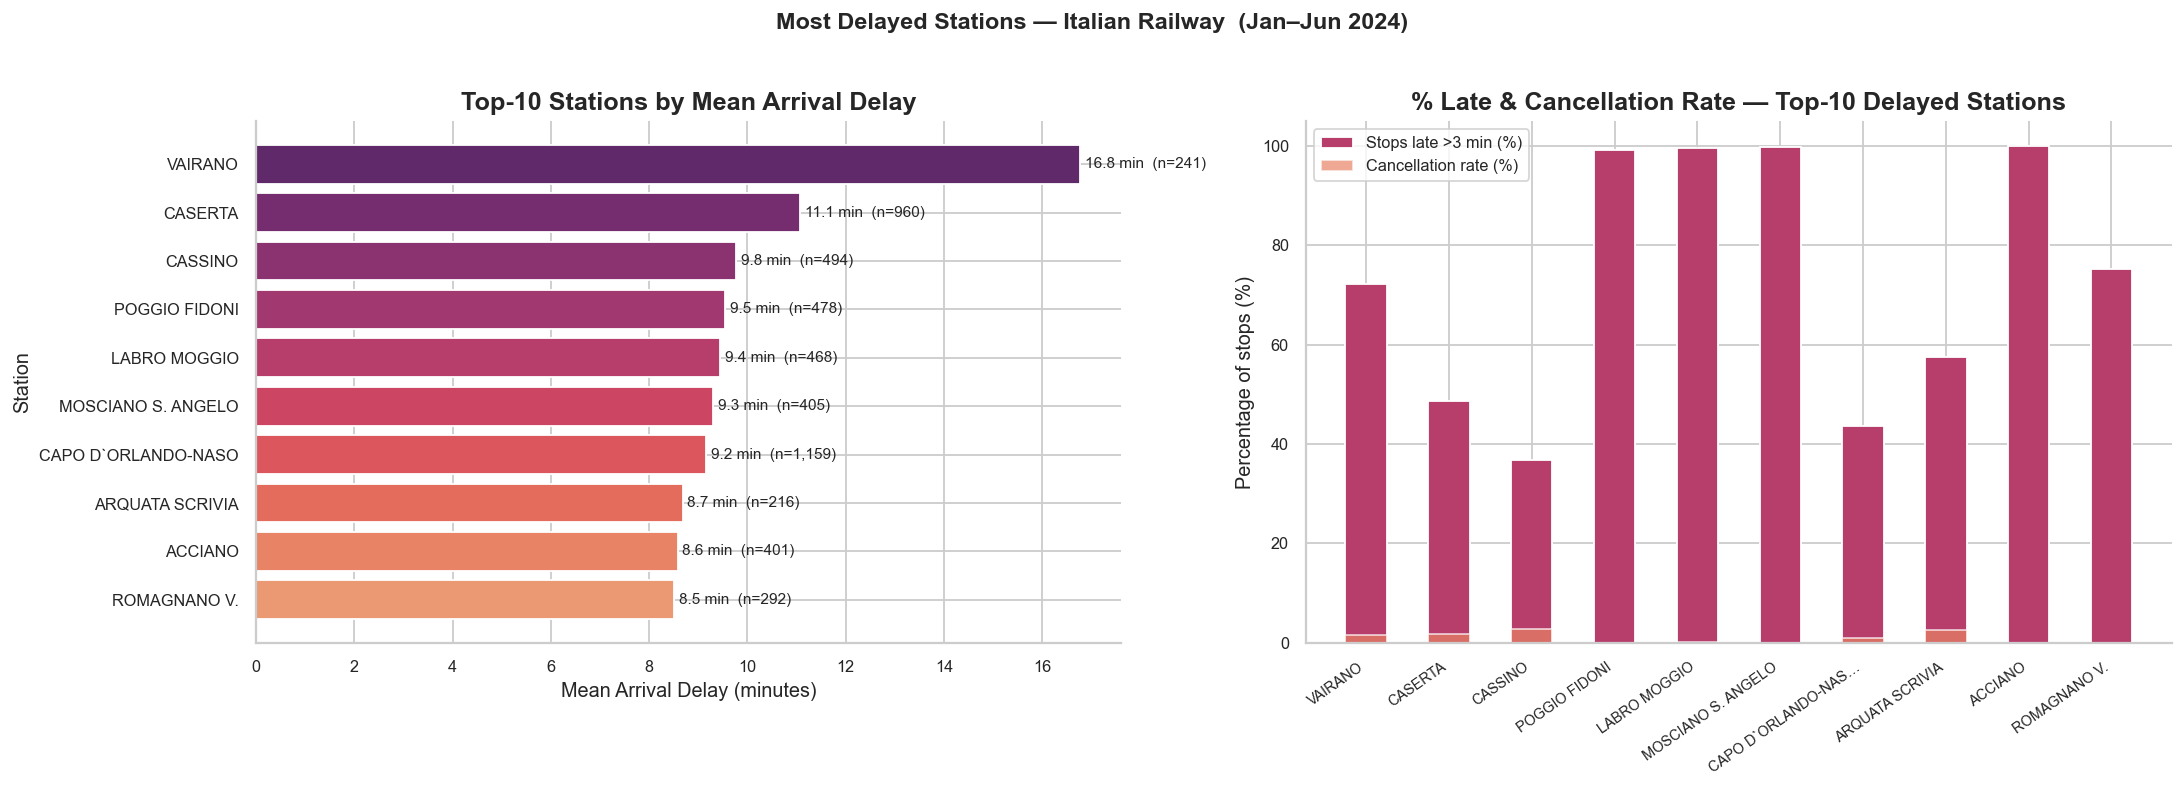

In [19]:
MIN_STOPS = 200

station_stats = (
    ops
    .dropna(subset=["station_name"])
    .groupby("station_name", observed=True)
    .agg(
        mean_delay        = ("arrival_delay", lambda x: x[~ops.loc[x.index, "cancelled"]].mean()),
        pct_late          = ("arrival_delay", lambda x: (x[~ops.loc[x.index, "cancelled"]] > 3).mean() * 100),
        cancellation_rate = ("cancelled",     lambda x: x.mean() * 100),
        n_stops           = ("arrival_delay", "count"),
    )
    .query("n_stops >= @MIN_STOPS")
    .sort_values("mean_delay", ascending=False)
    .reset_index()
)

top10 = station_stats.head(10)
display(top10.round(2))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
palette_s = sns.color_palette("flare", n_colors=10)

# ── Left: mean delay ─────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(
    top10["station_name"][::-1], top10["mean_delay"][::-1],
    color=palette_s, edgecolor="white",
)
for bar, val, n in zip(bars, top10["mean_delay"][::-1], top10["n_stops"][::-1]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f} min  (n={n:,})",
        va="center", fontsize=8.5,
    )
ax.set_title("Top-10 Stations by Mean Arrival Delay")
ax.set_xlabel("Mean Arrival Delay (minutes)")
ax.set_ylabel("Station")

# ── Right: % late & cancellation rate stacked ────────────────────────────────
ax2 = axes[1]
x_pos = range(len(top10))
labels_short = [
    name[:18] + "…" if len(name) > 18 else name
    for name in top10["station_name"]
]
ax2.bar(x_pos, top10["pct_late"],          color=palette_s[5], label="Stops late >3 min (%)",     width=0.5)
ax2.bar(x_pos, top10["cancellation_rate"], color=palette_s[1], label="Cancellation rate (%)", width=0.5, alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels_short, rotation=35, ha="right", fontsize=8)
ax2.set_title("% Late & Cancellation Rate — Top-10 Delayed Stations")
ax2.set_ylabel("Percentage of stops (%)")
ax2.legend(fontsize=9)

plt.suptitle("Most Delayed Stations — Italian Railway  (Jan–Jun 2024)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

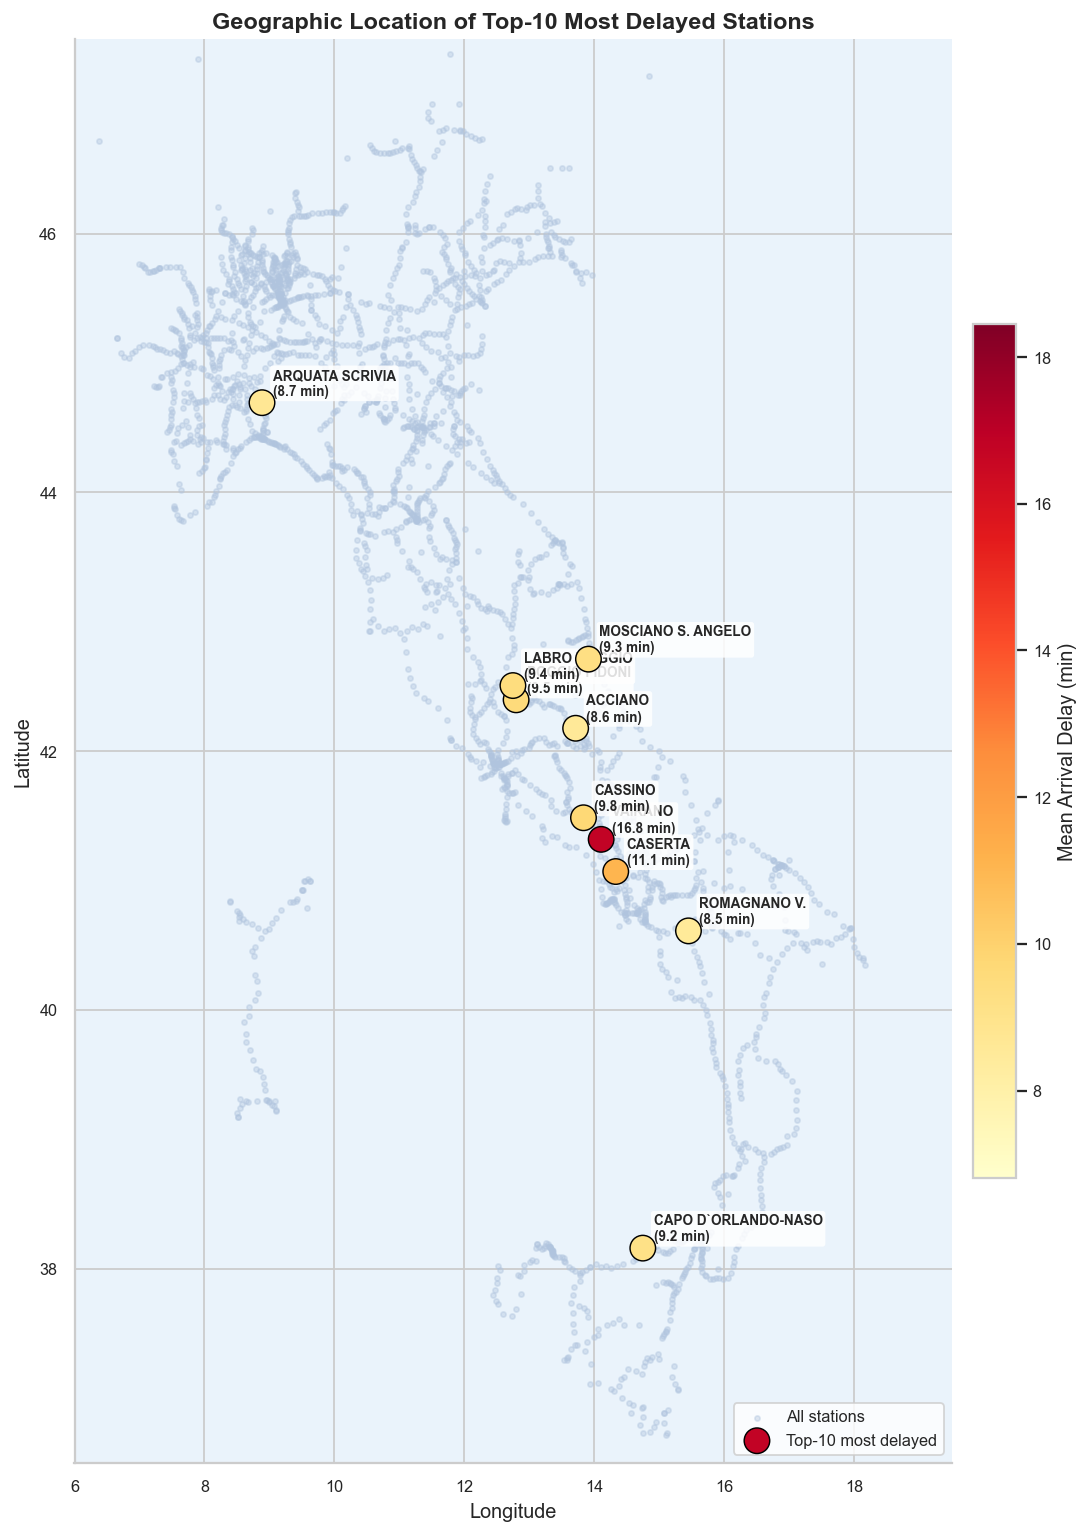

In [20]:
# ── Map the top-10 worst stations ─────────────────────────────────────────────
top10_geo = top10.merge(
    stations[["name", "lat", "lon", "id_region"]],
    left_on="station_name", right_on="name",
    how="left",
)

# Fallback: try the mileage file if station master doesn't match
unmatched = top10_geo[top10_geo["lat"].isna()]
if not unmatched.empty:
    mileage_coords = mileage.groupby("station_name")[["lat", "lon"]].first().reset_index()
    for idx, row in unmatched.iterrows():
        match = mileage_coords[mileage_coords["station_name"] == row["station_name"]]
        if not match.empty:
            top10_geo.loc[idx, "lat"] = match["lat"].values[0]
            top10_geo.loc[idx, "lon"] = match["lon"].values[0]

fig, ax = plt.subplots(figsize=(9, 12))
ax.set_facecolor("#eaf3fb")

# Background: all stations (faint)
ax.scatter(
    stations["lon"], stations["lat"],
    s=8, color="#b0c4de", alpha=0.4, zorder=1, label="All stations",
)

# Overlay top-10 worst stations
geo_ok = top10_geo.dropna(subset=["lat", "lon"])
scatter = ax.scatter(
    geo_ok["lon"], geo_ok["lat"],
    c=geo_ok["mean_delay"],
    cmap="YlOrRd",
    s=200, zorder=5, edgecolors="black", linewidths=0.8,
    vmin=geo_ok["mean_delay"].min() * 0.8,
    vmax=geo_ok["mean_delay"].max() * 1.1,
    label="Top-10 most delayed",
)
plt.colorbar(scatter, ax=ax, label="Mean Arrival Delay (min)", shrink=0.6, pad=0.02)

for _, row in geo_ok.iterrows():
    label_text = (
        row["station_name"][:20] + "…"
        if len(row["station_name"]) > 20
        else row["station_name"]
    )
    ax.annotate(
        f"{label_text}\n({row['mean_delay']:.1f} min)",
        xy=(row["lon"], row["lat"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=7.5, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0),
    )

ax.set_xlim(6, 19.5)
ax.set_ylim(36.5, 47.5)
ax.set_title("Geographic Location of Top-10 Most Delayed Stations",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

---
## 6 · Bonus: Monthly Delay Trend & Temperature Correlation

Two supplementary plots that extend the EDA:
1. **Monthly mean delay trend** — tracks whether punctuality improved or worsened across the six months
2. **Temperature vs. delay scatter** — tests whether cold (winter) temperatures correlate with higher delays

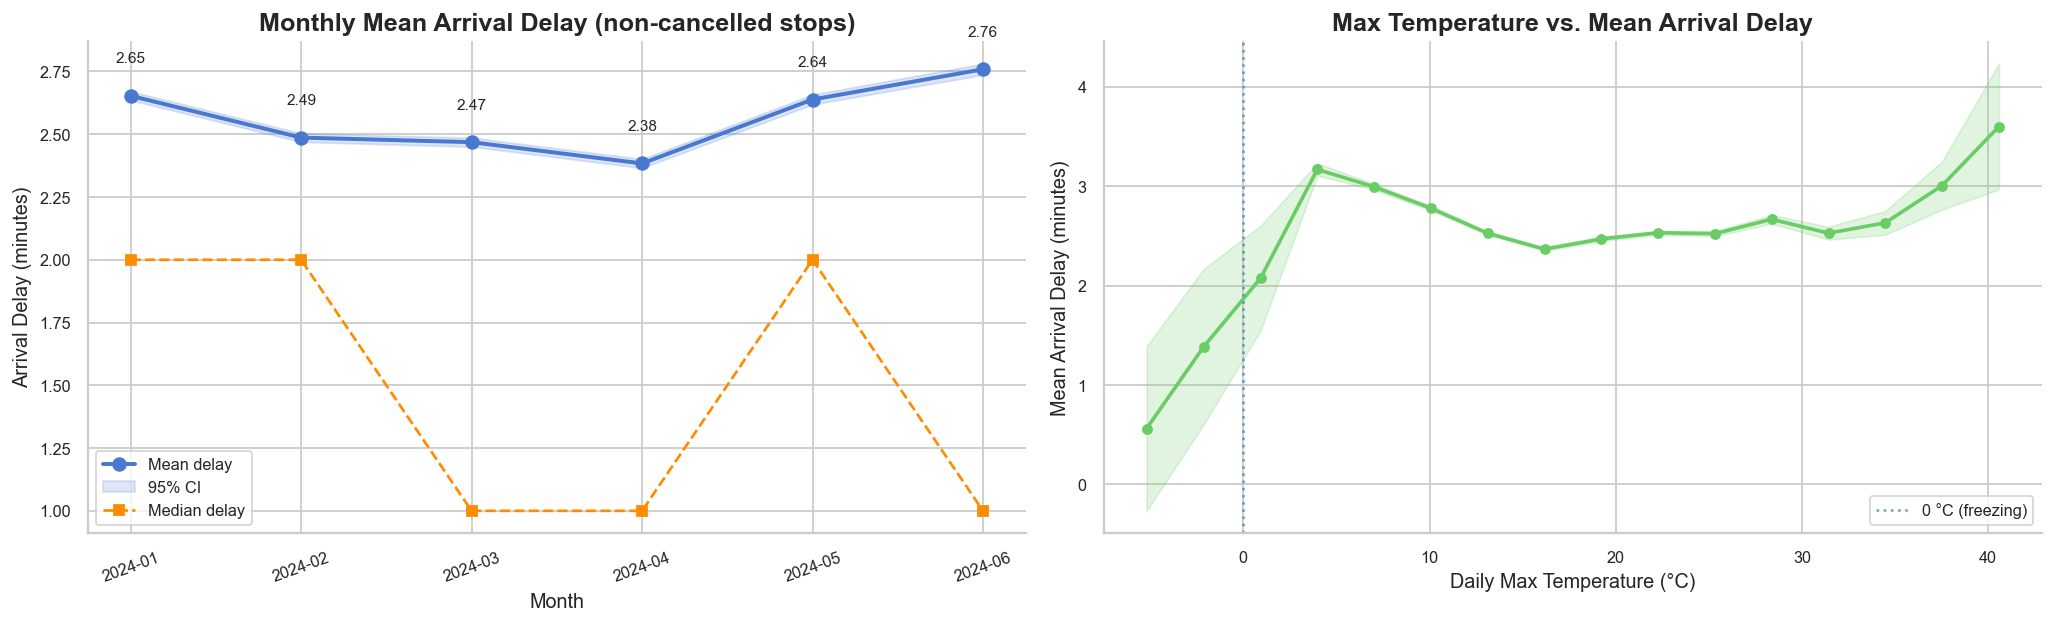

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: monthly mean delay ──────────────────────────────────────────────────
ax = axes[0]
monthly = (
    ops_nc
    .assign(month=ops_nc["date"].dt.to_period("M").astype(str))
    .groupby("month")["arrival_delay"]
    .agg(["mean", "median", "sem"])
    .reset_index()
)
ax.plot(monthly["month"], monthly["mean"], marker="o", ms=7,
        lw=2.2, color=sns.color_palette("muted")[0], label="Mean delay")
ax.fill_between(
    monthly["month"],
    monthly["mean"] - 1.96 * monthly["sem"],
    monthly["mean"] + 1.96 * monthly["sem"],
    alpha=0.18, color=sns.color_palette("muted")[0], label="95% CI",
)
ax.plot(monthly["month"], monthly["median"], marker="s", ms=5,
        lw=1.5, ls="--", color="darkorange", label="Median delay")
for _, row in monthly.iterrows():
    ax.text(row["month"], row["mean"] + 0.12, f"{row['mean']:.2f}",
            ha="center", va="bottom", fontsize=8.5)
ax.set_title("Monthly Mean Arrival Delay (non-cancelled stops)")
ax.set_xlabel("Month")
ax.set_ylabel("Arrival Delay (minutes)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)

# ── Right: temperature vs mean delay (binned) ─────────────────────────────────
ax2 = axes[1]
if "temperature_max" in ops_nc.columns:
    sub = ops_nc.dropna(subset=["temperature_max", "arrival_delay"])
    bins = pd.cut(sub["temperature_max"], bins=16)
    grp  = sub.groupby(bins, observed=True)["arrival_delay"]
    means = grp.mean()
    sems  = grp.sem()
    mids  = [iv.mid for iv in means.index]

    color_t = sns.color_palette("muted")[2]
    ax2.plot(mids, means.values, marker="o", ms=5, lw=2, color=color_t)
    ax2.fill_between(
        mids,
        (means - 1.96 * sems).values,
        (means + 1.96 * sems).values,
        alpha=0.2, color=color_t,
    )
    ax2.axvline(0, color="steelblue", ls=":", lw=1.5, alpha=0.7, label="0 °C (freezing)")
    ax2.set_title("Max Temperature vs. Mean Arrival Delay")
    ax2.set_xlabel("Daily Max Temperature (°C)")
    ax2.set_ylabel("Mean Arrival Delay (minutes)")
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, "temperature_max not available",
             ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

---
## 7 · Dataset Summary

A concise overview of the cleaned dataset, ready for downstream modelling.

In [22]:
print("═" * 65)
print("  Italian Railway Dataset — Cleaned Summary (Jan–Jun 2024)")
print("═" * 65)
print(f"  Operational stops        : {len(ops):>12,}")
print(f"  Date range               : {ops['date'].min().date()} → {ops['date'].max().date()}")
print(f"  Train classes            : {', '.join(ops['train_class'].cat.categories.tolist())}")
print(f"  Unique train IDs         : {ops['train_id'].nunique():>12,}")
print(f"  Unique stations          : {ops['station_name'].nunique():>12,}")
print(f"  Cancelled stops          : {ops['cancelled'].sum():>12,}  ({ops['cancelled'].mean()*100:.2f}%)")
valid_delays = ops.loc[~ops['cancelled'], 'arrival_delay'].dropna()
print(f"  Mean arrival delay       : {valid_delays.mean():>12.2f} min")
print(f"  Median arrival delay     : {valid_delays.median():>12.1f} min")
print(f"  Late stops (>3 min)      : {(valid_delays > 3).mean()*100:>11.1f}%")
print(f"  Fault events (full log)  : {len(faults):>12,}")
print(f"  Station master records   : {len(stations):>12,}")
print(f"  Route-station mileage rows: {len(mileage):>11,}")
print(f"  Residual NaN in ops      : {ops.isnull().any().sum():>12,} columns with any NaN")
print("═" * 65)

KEY_COLS = ["arrival_delay", "departure_delay", "temperature_min",
            "temperature_max", "wind_speed", "final_delay"]
key_present = [c for c in KEY_COLS if c in ops.columns]
print("\nDescriptive statistics — key numeric columns:")
display(ops[key_present].describe().T.round(3))

═════════════════════════════════════════════════════════════════
  Italian Railway Dataset — Cleaned Summary (Jan–Jun 2024)
═════════════════════════════════════════════════════════════════
  Operational stops        :    2,678,291
  Date range               : 2024-01-01 → 2024-06-30
  Train classes            : EC, FA, FB, FR, IC, ICN, REG
  Unique train IDs         :        3,324
  Unique stations          :        1,397
  Cancelled stops          :       17,279  (0.65%)
  Mean arrival delay       :         2.56 min
  Median arrival delay     :          1.0 min
  Late stops (>3 min)      :        26.4%
  Fault events (full log)  :          113
  Station master records   :        2,976
  Route-station mileage rows:      12,173
  Residual NaN in ops      :           10 columns with any NaN
═════════════════════════════════════════════════════════════════

Descriptive statistics — key numeric columns:


,count,mean,std,min,25%,50%,75%,max
arrival_delay,2318426.0,2.564,5.947,-66.0,0.0,1.0,4.0,308.0
departure_delay,2318509.0,3.718,5.586,-56.0,1.0,2.0,5.0,259.0
temperature_min,2678291.0,8.519,5.813,-26.0,4.5,8.3,12.8,30.2
temperature_max,2678291.0,17.529,6.400,-6.7,13.1,17.0,22.3,42.1
wind_speed,2678291.0,14.285,6.590,2.1,9.4,12.7,17.7,70.3


---
## Summary & Next Steps

### Key findings

| Finding | Detail |
|---------|--------|
| **Service cancellations** | Cancellation rates vary significantly by weather type. Counterintuitively, the data reveals that light rain exhibits the highest suspension rate (0.724), followed by moderate snow (0.681). Notably, heavy snow events (0.579) have a lower cancellation rate than simple cloudy days (0.668), suggesting that the railway infrastructure is highly resilient and well-adapted to severe winter conditions, while more susceptible to disruptions under milder, yet potentially technically disruptive, weather patterns. |
| **Train-class hierarchy** | The data reveals counterintuitive performance patterns across train classes. While premium high-speed services (FR) maintain competitive punctuality despite their massive operational volume, secondary high-speed services (FA) exhibit higher average delays (7.12 min) and frequency of lateness (51.06\%), performing similarly to conventional Intercity (IC) trains. Notably, overnight services (ICN) do not show a pattern of continuous delay accumulation; rather, they boast the lowest median delay (1.0 min) and lowest percentage of late arrivals (38.60\%). However, their exceptionally high standard deviation (20.58) indicates an extreme variance profile: ICN services are highly punctual on average due to buffered overnight schedules, but are susceptible to severe, anomalous disruption events when failures occur. |
| **Weather signal** | The data confirms that weather conditions provide a valid predictive signal (\texttt{weather\_severity}). Precipitation intensity demonstrates a clear positive correlation with mean delays, peaking during heavy rain events (3.33 min). However, snow conditions exhibit a non-linear impact on average punctuality, with moderate snow yielding slightly lower mean delays (2.48 min) than baseline cloudy days (2.49 min). Importantly, while the correlation exists, the absolute variance in mean delays across all weather categories is narrow (less than 1 minute). This suggests that severe weather impacts the network primarily through service cancellations (as noted above) rather than drastically inflating the average delay of surviving operations. |
| **Spatial clustering** | Geographic analysis of the most-delayed stations reveals profound network bottlenecks along specific corridors. For instance, the top three most delayed stations (Vairano, Caserta, and Cassino, with mean delays of 16.77, 11.07, and 9.76 minutes, respectively) form a continuous sequence on the historical Rome-Naples inland corridor, demonstrating how cascading delays propagate through congested infrastructure. Furthermore, the data exposes severe structural anomalies: stations such as Acciano, Mosciano S. Angelo, and Labro Moggio exhibit lateness rates approaching or exactly hitting 100\%. Such extreme \texttt{pct\_late} metrics indicate that these delays are not caused by stochastic operational disruptions or temporary bottlenecks, but rather by chronic timetable misalignment or permanent infrastructure speed restrictions that render the scheduled times physically unattainable. |


### Suggested next steps

1. **Route-level analysis** — join `ops` with `mileage` on `station_name` to compute delay propagation along each route (do early-stop delays predict later-stop delays?).
2. **Predictive modelling** — use `train_class`, `weather_severity`, `temperature_max`, `wind_speed`, `holiday`, `week`, `station_order`, and `initial_delay` as features to predict `arrival_delay`.
3. **Fault impact quantification** — join `fault_daily` with the operational data on date + line to measure how much additional delay fault-days produce vs. fault-free days.
4. **Network graph** — build a station adjacency graph from `mileage` using NetworkX; compute betweenness centrality to identify structurally critical stations.
5. **Causal inference** — use propensity-score matching to estimate the causal effect of adverse weather on delays, controlling for time-of-day and route confounders.

---
*Notebook for the Italian Railway Disruption Prediction dataset.*  
*Reference: Nature Scientific Data, 2025 — https://www.nature.com/articles/s41597-025-06385-8*